# Task (b) — Detector effects and the 10,000-event dataset

Task (a) gave me perfect hits. Real detectors aren't perfect, so here I add two
effects and then scale the simulation up to the full dataset.

The first effect is efficiency: each ideal hit is only recorded 95% of the time,
independently. This means events no longer all have the same number of hits. A
10-track event has 50 ideal hits but records about 47.5 on average, and the
recorded count per track follows a Binomial(5, 0.95).

The second effect is position smearing: I add independent Gaussian noise to each
recorded hit's x and y. The exam says a standard deviation of 0.1 percent, I
read that as 0.1% of the hit's radius, so sigma = 0.001*R on each coordinate. I
chose the radius-relative form because it behaves like a relative measurement
precision and stays isotropic, and because it's just a parameter it's easy to
change if needed.

Finally I generate the full dataset: 10,000 events with 10 tracks each, with both
effects switched on.

### Setup


In [8]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- simulator ----
COLUMNS = ["event_id", "track_id", "layer", "x", "y", "phi"]


def detector_radii(n_circles: int = 5, spacing: float = 2.0) -> np.ndarray:
    # The five detector circles, equally spaced. Defaults give [2,4,6,8,10].
    return spacing * np.arange(1, n_circles + 1)


def sample_track_angles(n_tracks: int,
                        rng: np.random.Generator,
                        min_sep: float = 0.0) -> np.ndarray:
    if min_sep <= 0.0:
        return rng.uniform(0.0, 2.0 * np.pi, size=n_tracks)

    phis: list[float] = []
    while len(phis) < n_tracks:
        cand = rng.uniform(0.0, 2.0 * np.pi)
        if all(_angular_gap(cand, p) >= min_sep for p in phis):
            phis.append(cand)
    return np.array(phis)


def _angular_gap(a: float, b: float) -> float:
    d = abs(a - b) % (2.0 * np.pi)
    return min(d, 2.0 * np.pi - d)


def track_hits(phi: float, radii: np.ndarray) -> np.ndarray:
    x = radii * np.cos(phi)
    y = radii * np.sin(phi)
    return np.column_stack([x, y])


def simulate_event(event_id: int,
                   n_tracks: int = 3,
                   n_circles: int = 5,
                   spacing: float = 2.0,
                   efficiency: float = 1.0,
                   smear: float = 0.0,
                   min_sep: float = 0.0,
                   rng: np.random.Generator | None = None) -> pd.DataFrame:
    if rng is None:
        rng = np.random.default_rng()

    radii = detector_radii(n_circles, spacing)
    phis = sample_track_angles(n_tracks, rng, min_sep=min_sep)

    rows = []
    for track_id, phi in enumerate(phis):
        hits = track_hits(phi, radii)                
        keep = rng.random(n_circles) < efficiency
        layers = np.nonzero(keep)[0]
        hits = hits[keep]

        if smear > 0.0 and len(hits):
            sigma = smear * radii[keep]
            noise = rng.normal(0.0, 1.0, hits.shape) * sigma[:, None]
            hits = hits + noise

        for layer, (x, y) in zip(layers, hits):
            rows.append((event_id, track_id, layer, x, y, phi))

    return pd.DataFrame(rows, columns=COLUMNS)


def simulate_events(n_events: int, seed: int | None = None, **kwargs) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    frames = [simulate_event(i, rng=rng, **kwargs) for i in range(n_events)]
    return pd.concat(frames, ignore_index=True)


# ---- plotting ----
_COLORS = plt.cm.tab10.colors
def draw_detector(ax, radii):
    for r in radii:
        ax.add_patch(plt.Circle((0, 0), r, fill=False, color="tab:blue", lw=1.1))


def plot_event(event, ax=None, radii=None, show_rays=True, legend=True):
    if radii is None:
        radii = detector_radii(5, 2.0)
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    R = radii.max()
    draw_detector(ax, radii)

    for track_id, g in event.groupby("track_id"):
        c = _COLORS[track_id % 10]
        if show_rays:
            phi = g["phi"].iloc[0]
            ax.plot([0, R * np.cos(phi)], [0, R * np.sin(phi)],
                    color=c, lw=1, alpha=0.5)
        ax.scatter(g["x"], g["y"], color=c, s=35, zorder=3,
                   label=f"track {track_id}")

    lim = R * 1.1
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    if legend:
        ax.legend(loc="upper right", fontsize=8)
    return ax

from math import comb
RADII = detector_radii(5, 2.0); SMEAR = 0.001; EFF = 0.95

## 1. One realistic event
A single 10-track event, showing only the recorded hits. Some tracks now have
fewer than 5 points because a few hits were dropped by the efficiency.

recorded hits: 48 (ideal = 50)


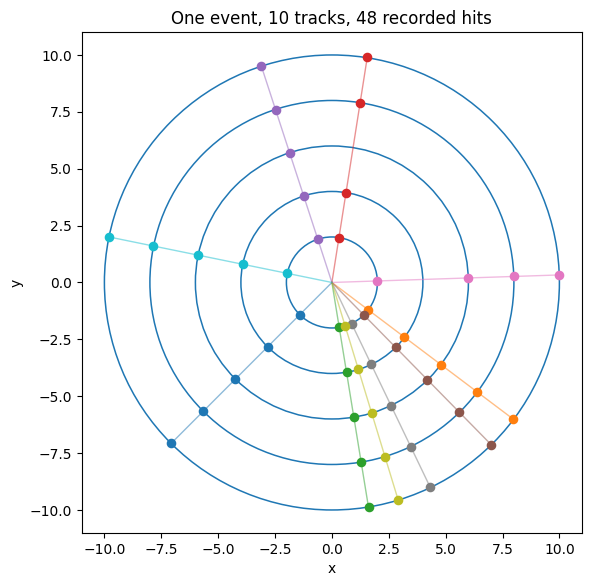

In [9]:
ev = simulate_event(0, n_tracks=10, efficiency=EFF, smear=SMEAR,
                    rng=np.random.default_rng(7))
print(f"recorded hits: {len(ev)} (ideal = 50)")
fig, ax = plt.subplots(figsize=(6.5, 6.5))
plot_event(ev, ax=ax, radii=RADII, legend=False)
ax.set_title(f"One event, 10 tracks, {len(ev)} recorded hits"); plt.show()

## 2. Generate the 10,000-event dataset
This is the dataset the rest of the project uses. I save it to `data/`, but it's
fully reproducible from this cell.

In [10]:
df = simulate_events(10000, seed=2026, n_tracks=10, efficiency=EFF, smear=SMEAR)
os.makedirs("data", exist_ok=True)
df.to_csv("data/events_2d_10k.csv", index=False)
print(f"{len(df):,} hit rows from 10,000 events")
df.head()

475,028 hit rows from 10,000 events


,event_id,track_id,layer,x,y,phi
0,0,0,1,1.724846,3.606214,1.124281
1,0,0,2,2.594243,5.410960,1.124281
2,0,0,3,3.443609,7.211839,1.124281
3,0,0,4,4.324821,9.017249,1.124281
4,0,1,0,-1.278149,-1.539981,4.020693


## 3. Efficiency check — event level
As a check, the number of recorded hits per event should scatter around
50 * 0.95 = 47.5.

mean hits/event: 47.5028


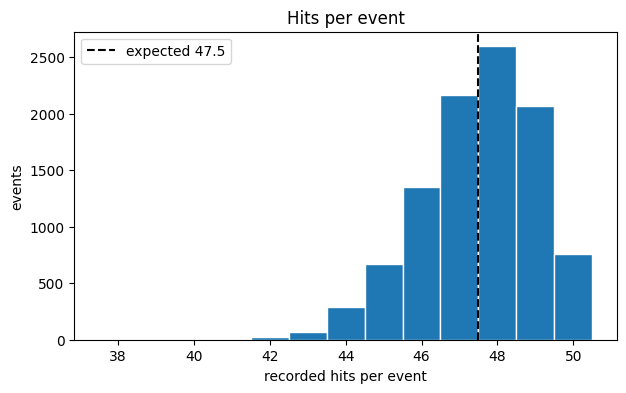

In [11]:
per_event = df.groupby("event_id").size()
print("mean hits/event:", per_event.mean())
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(per_event, bins=np.arange(38, 52)-0.5, color="tab:blue", edgecolor="white")
ax.axvline(47.5, color="k", ls="--", label="expected 47.5")
ax.set_xlabel("recorded hits per event"); ax.set_ylabel("events")
ax.set_title("Hits per event"); ax.legend(); plt.show()

## 4. Efficiency check — track level
A tighter check: the number of hits recorded per track should follow a
Binomial(5, 0.95) exactly, since each of a track's 5 hits survives independently
with probability 0.95.

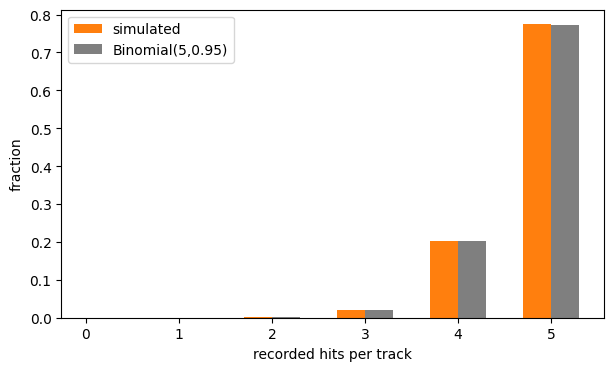

In [12]:
per_track = df.groupby(["event_id","track_id"]).size()
frac = per_track.value_counts(normalize=True).sort_index()
k = np.arange(0, 6)
binom = np.array([comb(5,i)*EFF**i*(1-EFF)**(5-i) for i in k])
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(frac.index-0.15, frac.values, width=0.3, label="simulated", color="tab:orange")
ax.bar(k+0.15, binom, width=0.3, label="Binomial(5,0.95)", color="tab:gray")
ax.set_xlabel("recorded hits per track"); ax.set_ylabel("fraction"); ax.set_xticks(k)
ax.legend(); plt.show()

## 5. Smearing, made visible
The smearing (sigma up to 0.01) is tiny next to the circle spacing of 2, so it's
invisible in a normal event plot. To actually see it, I measure the *same* hit
3000 times and look at the spread. This also shows the outer hit at R=10 smears
5x more than the inner one at R=2, which is the point of the radius-relative
noise.

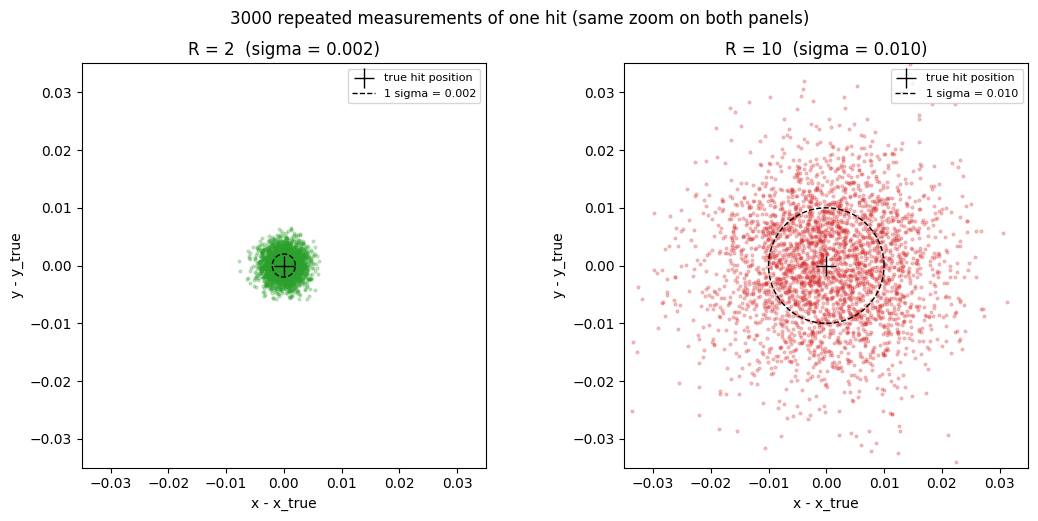

In [13]:
rng = np.random.default_rng(0); N = 3000; phi = 0.6
WIN = 0.035       
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
for ax, (R, col) in zip(axes, [(2.0, "tab:green"), (10.0, "tab:red")]):
    x0, y0 = R*np.cos(phi), R*np.sin(phi); sig = SMEAR*R
    dx = rng.normal(0, sig, N); dy = rng.normal(0, sig, N)   # deviations from the true hit
    ax.scatter(dx, dy, s=4, alpha=0.25, color=col)
    ax.plot(0, 0, "k+", ms=14, label="true hit position")
    # 1-sigma circle for reference
    tt = np.linspace(0, 2*np.pi, 200)
    ax.plot(sig*np.cos(tt), sig*np.sin(tt), "k--", lw=1, label=f"1 sigma = {sig:.3f}")
    ax.set_xlim(-WIN, WIN); ax.set_ylim(-WIN, WIN); ax.set_aspect("equal")
    ax.set_xlabel("x - x_true"); ax.set_ylabel("y - y_true")
    ax.set_title(f"R = {R:.0f}  (sigma = {sig:.3f})"); ax.legend(loc="upper right", fontsize=8)
fig.suptitle("3000 repeated measurements of one hit (same zoom on both panels)")
fig.tight_layout(); plt.show()

## 6. Smearing magnitude check
To confirm the noise size is right, I take each hit's radial deviation from its
nominal radius and divide by the expected sigma = 0.001*R. If the smearing is
implemented correctly this normalised deviation should be a standard normal.

std of normalized deviation: 1.0


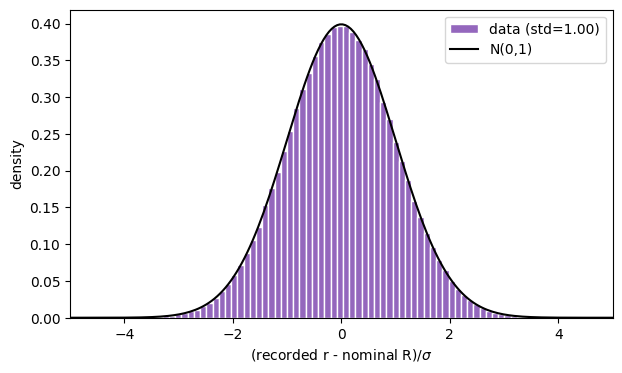

In [14]:
r = np.hypot(df["x"], df["y"]); nominal = RADII[df["layer"].to_numpy()]
dev = (r - nominal) / (SMEAR * nominal)
print("std of normalized deviation:", round(float(dev.std()), 3))
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(dev, bins=80, density=True, color="tab:purple", edgecolor="white",
        label=f"data (std={dev.std():.2f})")
xx = np.linspace(-5,5,200); ax.plot(xx, np.exp(-xx**2/2)/np.sqrt(2*np.pi), "k-",
                                     label="N(0,1)")
ax.set_xlabel(r"(recorded r - nominal R)/$\sigma$"); ax.set_ylabel("density")
ax.legend(); ax.set_xlim(-5,5); plt.show()

## Summary
In task (b) I added the two detector effects: 95% per-hit efficiency (which
makes hit counts vary) and Gaussian smearing with sigma = 0.001*R. I checked
each one statistically, hits per event average ~47.5, hits per track follow
Binomial(5, 0.95), and the normalised radial deviation is N(0,1). The resulting
dataset (about 475k hit rows) is what I histogram in task (c) and train on in
task (d).